Setting (library import, file load)

In [1]:
#library import

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats

from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

#from scipy.constants import precision

import statsmodels.formula.api as smf
import statsmodels.api as sm

%precision 3

%matplotlib inline

In [2]:
#read data

food_data = pd.read_csv("온라인음식서비스거래액.csv", engine="python", thousands = ',')
covid_data = pd.read_csv("코로나확진현황.csv", engine="python", thousands = ',')
covid_m_data = pd.read_csv("코로나확진현황(월간).csv", engine="python", thousands = ',')

food_data['date'] = pd.to_datetime(food_data['date'], format='%Y/%m')
covid_data['date'] = pd.to_datetime(covid_data['date'])
covid_m_data['date'] = pd.to_datetime(covid_m_data['date'], format='%Y.%m')

In [3]:
# merge data

merge = pd.merge(covid_m_data, food_data, on = 'date')
merge.head(3)

,date,infected,accrue,total,general,specific
0,2020-01-01,11,11,1063820,14676,1049144
1,2020-02-01,2920,2931,1135331,17340,1117991
2,2020-03-01,6855,9786,1252462,20297,1232165


1. relplot 그리기

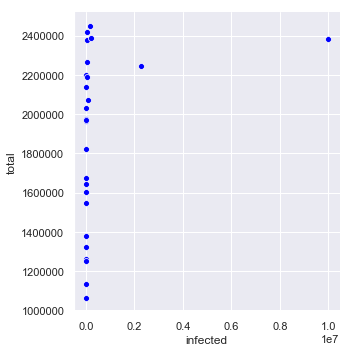

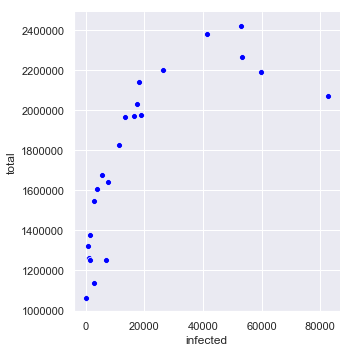

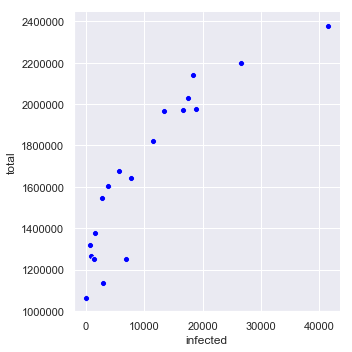

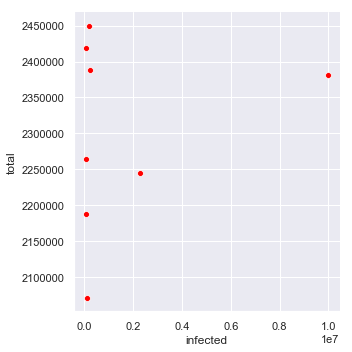

In [4]:
# 월별 신규확진자-온라인음식서비스 총거래액

sns.relplot(x='infected', y='total', data = merge, color='blue')

# scatter plot에서 확진자 수가 일정 기준 이상 커지면 경향을 벗어남
# 신규확진자 수 기준 데이터 정렬
# 확진자 수가 큰 후반 데이터 제거로 선형 scatter plot 찾기

merge_sort = merge.sort_values(by='infected')
sns.relplot(x='infected', y='total', data = merge_sort[:-4], color='blue')
sns.relplot(x='infected', y='total', data = merge_sort[:-8], color='blue')
sns.relplot(x='infected', y='total', data = merge_sort[-8:], color='red')


# merge_sort[:-8]를 merge_sort_slice 라는 변수로 새로 정의

merge_sort_slice = merge_sort[:-8]

2. lmplot 그리기

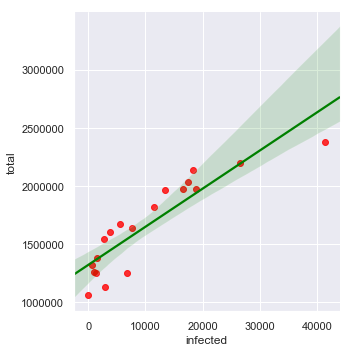

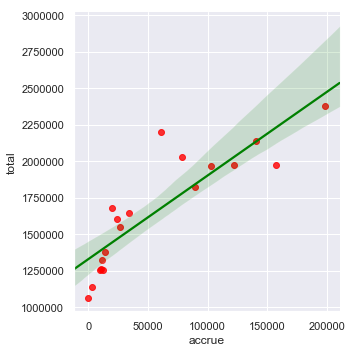

In [5]:
#lmplot 
# 신규확진자-온라인음식서비스 총거래액 
# 누적확진자-온라인음식서비스 총거래액 

sns.lmplot(x='infected', y='total', data=merge_sort_slice, scatter_kws={"color":"red"}, line_kws={"color":"green"})
sns.lmplot(x='accrue', y='total', data=merge_sort_slice, scatter_kws={"color":"red"}, line_kws={"color":"green"})

3. jointplot 그리기

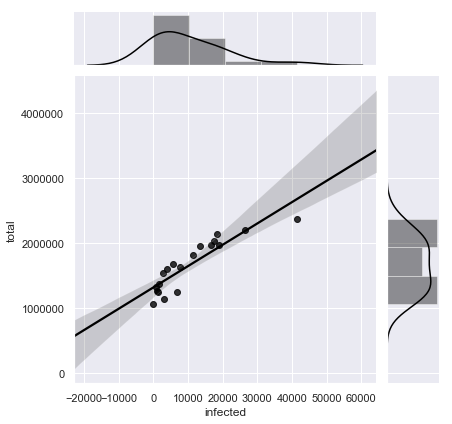

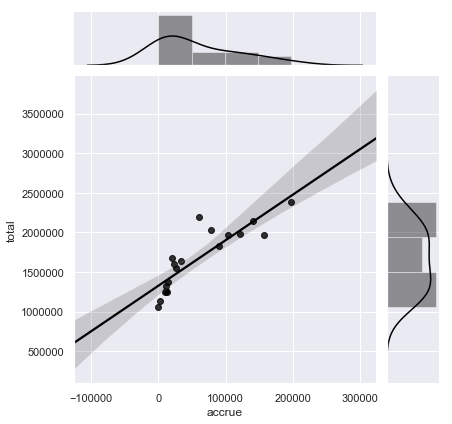

In [6]:
# jointplot (regression line 포함, 위쪽과 오른쪽은 밀집도를 나타냄) 
# 신규확진자-온라인음식서비스 총거래액 
# 누적확진자-온라인음식서비스 총거래액 

sns.jointplot(x='infected', y='total', data=merge_sort_slice, kind = 'reg', color = 'black')
sns.jointplot(x='accrue', y='total', data=merge_sort_slice, kind = 'reg', color = 'black')